<a href="https://www.kaggle.com/code/aashishthegreat/project?scriptVersionId=306481532" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## 1. Introduction

Customer churn prediction helps telecom providers identify customers likely to leave and take proactive retention actions.
This notebook analyzes the Telco Customer Churn dataset using exploratory analysis and machine learning models.
We compare baseline models and then improve performance using tuned ensemble methods (e.g., Gradient Boosting / XGBoost).

**Target:** `Churn` (Yes/No)
**Main metric:** ROC-AUC (threshold-independent, good for imbalanced classes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
sns.set_theme()

## 2. Dataset

We use the Telco Customer Churn dataset.
It contains customer demographics, service usage, billing information, and the churn label.

In [2]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

## 3. Data Cleaning & Preprocessing

Steps:
1. Convert `TotalCharges` to numeric (some rows contain blanks).
2. Drop rows with missing `TotalCharges`.
3. Drop `customerID` (identifier only).
4. Encode target `Churn` as 0/1.
5. One-hot encode categorical features.
6. Train/test split using stratification.

In [4]:
# --- Fix target safely (prevents: "Input y contains NaN") ---
df['Churn'] = df['Churn'].astype(str).str.strip()          # remove spaces
df = df[df['Churn'].isin(['Yes','No'])].copy()             # keep only valid rows
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})           # convert to 0/1

print("NaNs in y:", df['Churn'].isna().sum())
print(df['Churn'].value_counts())

NaNs in y: 0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df.drop('Churn', axis=1)
y = df['Churn']

# if you haven't already done get_dummies, do it here:
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5634, 13601) Test: (1409, 13601)


## 4. Exploratory Data Analysis (EDA)

We first examine churn class balance and basic relationships between churn and key variables.

Churn rate: 0.2653698707936959


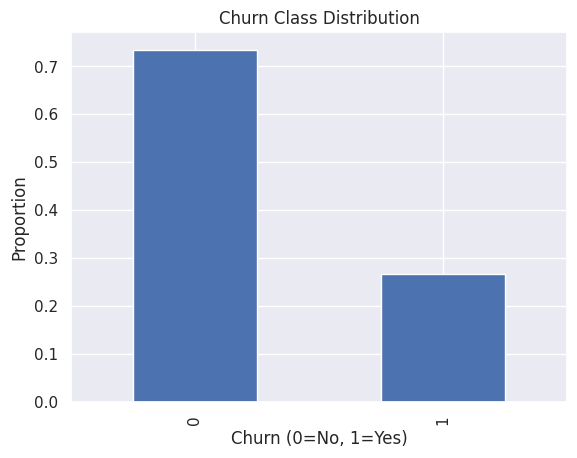

In [6]:
churn_rate = y.mean()
print("Churn rate:", churn_rate)

plt.figure()
y.value_counts(normalize=True).plot(kind='bar')
plt.title("Churn Class Distribution")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Proportion")
plt.show()

### 4.1 Tenure vs Churn

We expect customers with shorter tenure to churn more often.

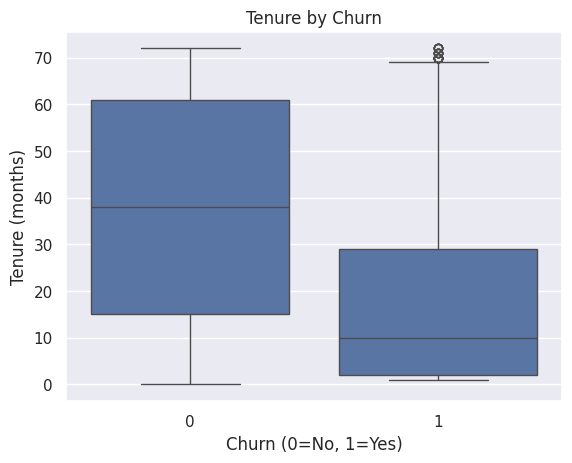

In [7]:
plt.figure()
sns.boxplot(x=df['Churn'], y=df['tenure'])
plt.title("Tenure by Churn")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Tenure (months)")
plt.show()

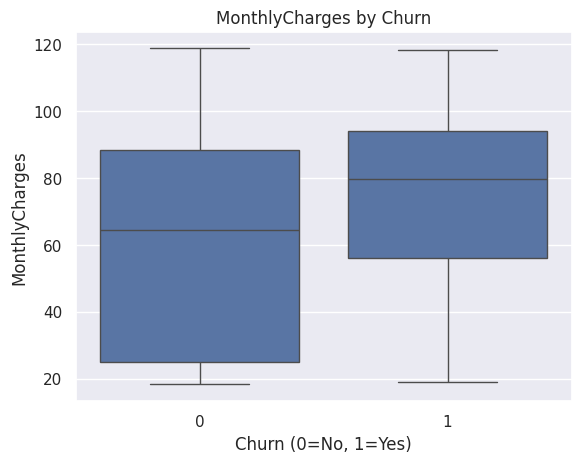

In [8]:
plt.figure()
sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'])
plt.title("MonthlyCharges by Churn")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("MonthlyCharges")
plt.show()

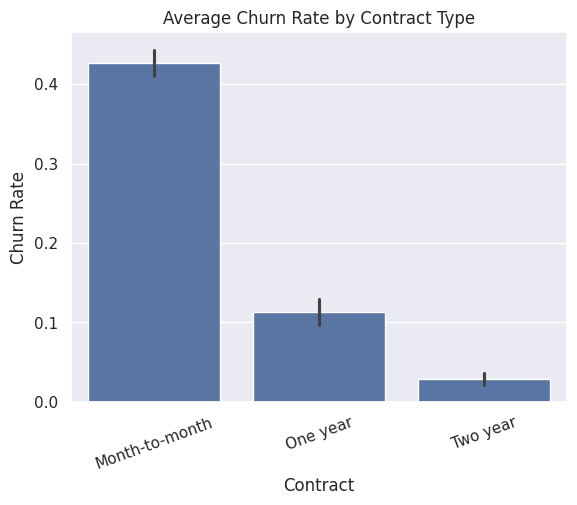

In [9]:
plt.figure()
sns.barplot(
    data=df,
    x='Contract',
    y='Churn',
    estimator=np.mean
)
plt.title("Average Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()

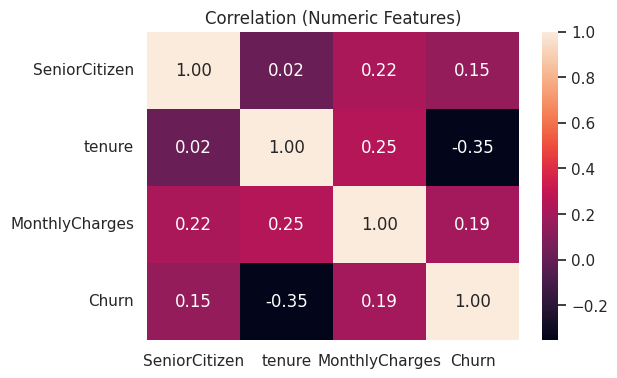

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation (Numeric Features)")
plt.show()

## 5. Baseline Models

We train three baseline models:
- Logistic Regression (interpretable baseline)
- Decision Tree (non-linear baseline)
- Random Forest (ensemble baseline)

We evaluate using Accuracy, Precision, Recall, F1, and ROC-AUC.

In [11]:
# Identify columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)  # We'll one-hot encode in next step using get_dummies approach OR use OneHotEncoder
    ],
    remainder="drop"
)

# Better: use OneHotEncoder directly (clean + reproducible)
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, "predict_proba") else None

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob) if prob is not None else np.nan
    }
    return pipe, metrics, prob

In [12]:
results = []
probs = {}
models = {}

pipe_lr, m_lr, prob_lr = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test
)
results.append(m_lr)
probs["Logistic Regression"] = prob_lr
models["Logistic Regression"] = pipe_lr

pipe_dt, m_dt, prob_dt = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test
)
results.append(m_dt)
probs["Decision Tree"] = prob_dt
models["Decision Tree"] = pipe_dt

pipe_rf, m_rf, prob_rf = evaluate_model(
    "Random Forest",
    RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300),
    X_train, X_test, y_train, y_test
)
results.append(m_rf)
probs["Random Forest"] = prob_rf
models["Random Forest"] = pipe_rf

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.799858,0.682540,0.459893,0.549521,0.833071
0,Logistic Regression,0.763662,0.730337,0.173797,0.280778,0.819486
1,Decision Tree,0.765791,0.565868,0.505348,0.533898,0.682625


### Baseline Model Performance Across Core Metrics

We evaluate the baseline models using four key classification metrics: Accuracy, Precision, Recall, and F1-score. These metrics provide a comprehensive understanding of model performance from different perspectives.

- **Accuracy** measures overall correctness.
- **Precision** reflects how many predicted positives are actually correct.
- **Recall** indicates how well the model captures true positive cases.
- **F1-score** balances precision and recall, making it especially useful for imbalanced datasets.

From the visual comparison, we observe that ensemble-based methods such as Random Forest generally perform more consistently across all metrics. Simpler models like Decision Tree may show weaker and less stable performance.

The highlighted bars indicate the best-performing model for each metric, allowing for quick identification of the strongest baseline approach.

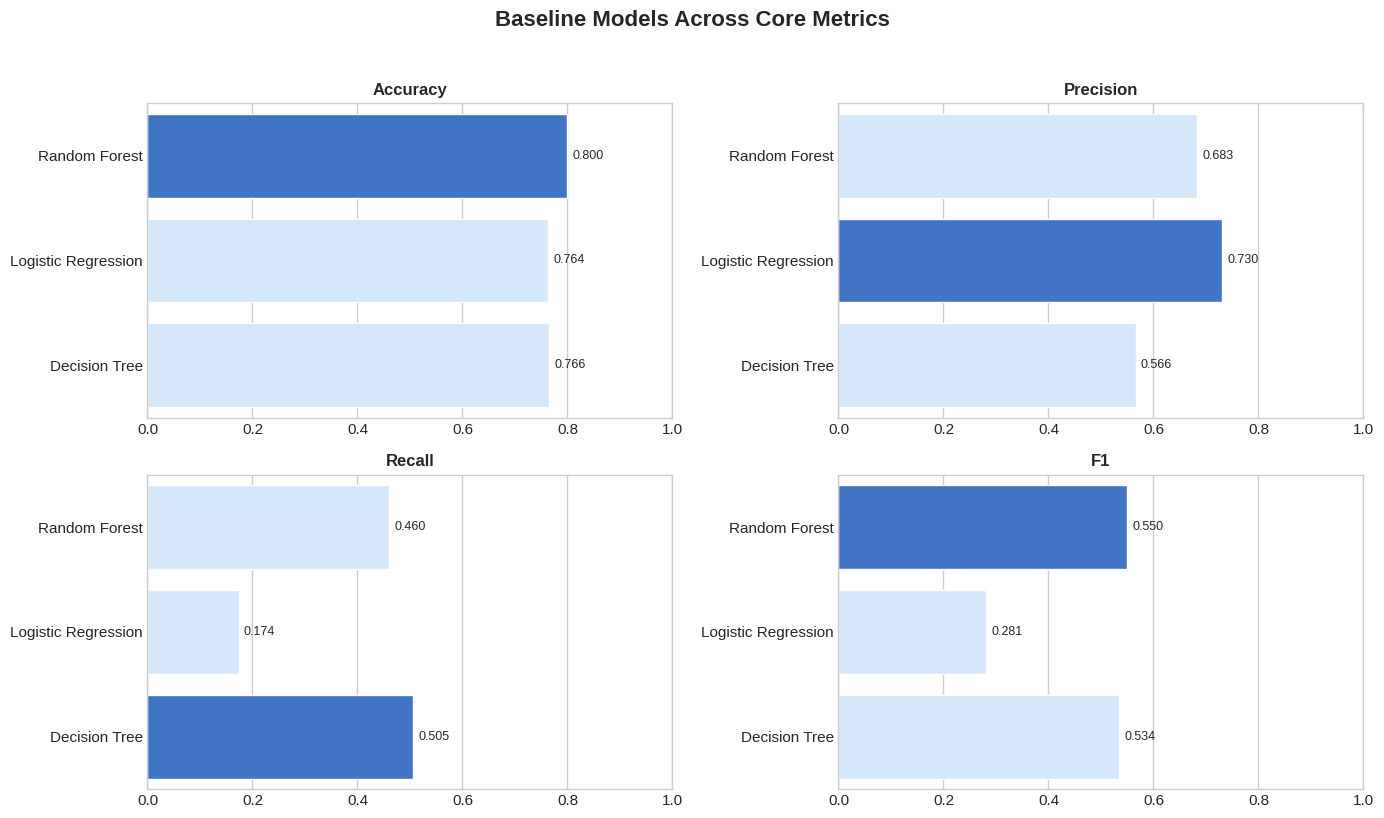

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

metrics = ["Accuracy", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    best_idx = results_df[metric].idxmax()

    colors = ["#cfe8ff"] * len(results_df)
    colors[list(results_df.index).index(best_idx)] = "#2a6fdb"

    sns.barplot(
        data=results_df,
        x=metric,
        y="Model",
        hue="Model",
        palette=colors,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_xlim(0, 1)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    for j, v in enumerate(results_df[metric]):
        axes[i].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Baseline Models Across Core Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### ROC-AUC Comparison

The ROC-AUC metric evaluates how well a model distinguishes between classes across different classification thresholds. It is particularly important for imbalanced datasets, as it measures ranking performance rather than relying on a fixed threshold.

The ROC-AUC bar chart provides a direct comparison of the models’ overall discriminative ability. Higher values indicate better performance, with a score of 0.5 representing random guessing.

In our baseline models, Random Forest achieves the highest ROC-AUC score, indicating superior ability to separate positive and negative classes. In contrast, the Decision Tree model shows comparatively lower performance.

The best-performing model is highlighted for clarity, making it easier to identify the most reliable baseline before proceeding to model improvements.

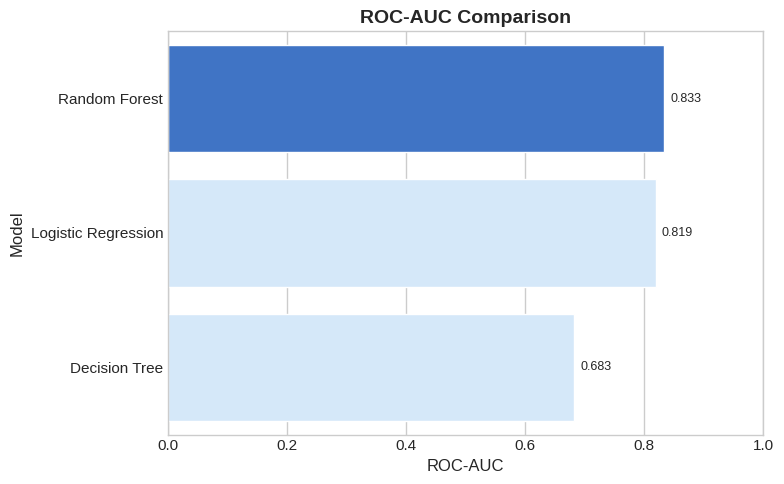

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Ensure proper indexing
results_df = results_df.reset_index(drop=True)

# Find best model
best_idx = results_df["ROC-AUC"].idxmax()

# Colors
colors = ["#cfe8ff"] * len(results_df)
colors[best_idx] = "#2a6fdb"

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model",
    hue="Model",
    palette=colors,
    legend=False
)

plt.title("ROC-AUC Comparison", fontsize=14, fontweight="bold")
plt.xlim(0, 1)

for i, v in enumerate(results_df["ROC-AUC"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### ROC Curve Comparison

The ROC curve evaluates how well each baseline model distinguishes between classes.
The dashed diagonal line represents a random classifier.
Models closer to the top-left corner indicate better performance.

We highlight the best-performing model based on AUC.

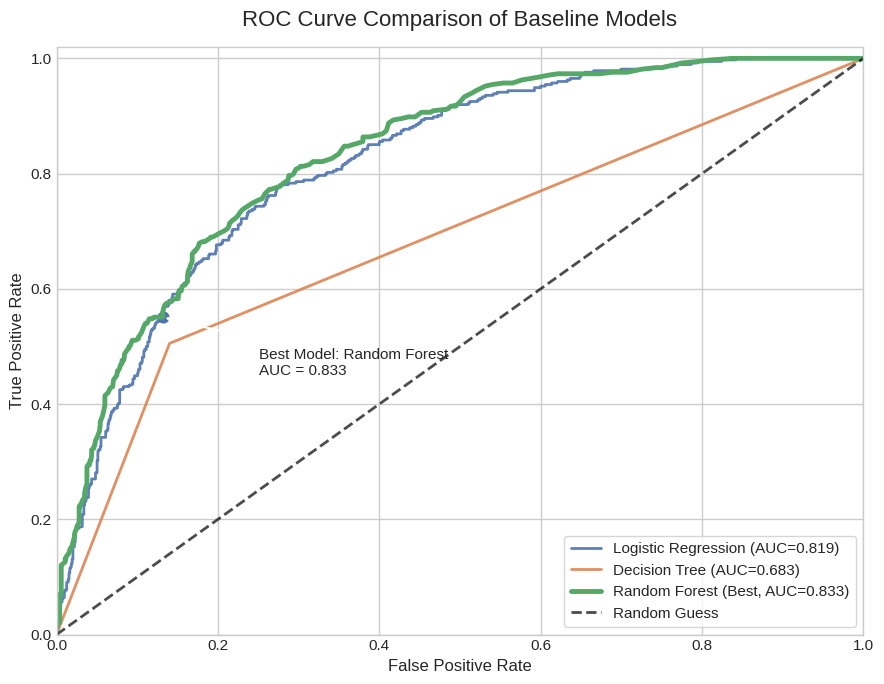

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9, 7))

best_model = None
best_auc = -1
best_fpr = None
best_tpr = None

# Find best model
for model_name, prob in probs.items():
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        roc_auc = auc(fpr, tpr)
        if roc_auc > best_auc:
            best_auc = roc_auc
            best_model = model_name
            best_fpr = fpr
            best_tpr = tpr

# Plot all models
for model_name, prob in probs.items():
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        roc_auc = auc(fpr, tpr)

        if model_name == best_model:
            plt.plot(
                fpr, tpr,
                linewidth=3.5,
                label=f"{model_name} (Best, AUC={roc_auc:.3f})"
            )
        else:
            plt.plot(
                fpr, tpr,
                linewidth=2,
                alpha=0.9,
                label=f"{model_name} (AUC={roc_auc:.3f})"
            )

# Random baseline
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.7,
    label="Random Guess"
)

# Annotate best model near middle of its curve
mid_idx = len(best_fpr) // 2
plt.scatter(best_fpr[mid_idx], best_tpr[mid_idx], s=60)
plt.annotate(
    f"Best Model: {best_model}\nAUC = {best_auc:.3f}",
    xy=(best_fpr[mid_idx], best_tpr[mid_idx]),
    xytext=(best_fpr[mid_idx] + 0.12, best_tpr[mid_idx] - 0.1),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11
)

plt.title("ROC Curve Comparison of Baseline Models", fontsize=16, pad=15)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", frameon=True, fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 6. Improved Models

To enhance performance beyond the baseline models, we apply advanced modeling techniques and hyperparameter optimization.

### 1. Hyperparameter Tuning (Random Forest)

We optimize the Random Forest model using **RandomizedSearchCV**, which efficiently searches over a range of hyperparameters. Key parameters tuned include:
- Number of trees (`n_estimators`)
- Maximum depth (`max_depth`)
- Minimum samples for splits and leaves
- Feature selection strategy (`max_features`)
- Class weighting to handle imbalance

We use **Stratified K-Fold Cross-Validation** to preserve class distribution and ensure reliable evaluation. The model is optimized using **ROC-AUC**, a robust metric for classification performance.

---

### 2. Gradient Boosting

We introduce **Gradient Boosting**, a powerful ensemble method that builds models sequentially to correct previous errors. This approach often captures complex patterns better than individual models.

---

### 3. XGBoost (Optional)

If available, we also train an **XGBoost model**, an advanced gradient boosting implementation known for its efficiency and high performance in structured data problems.

### Tuned Logistic Regression

To further strengthen the benchmark comparison, we also tune Logistic Regression using RandomizedSearchCV. The search focuses on regularization strength, solver choice, and class weighting.

Although Logistic Regression is a simpler model than ensemble methods, tuning helps improve fairness in comparison and shows whether a linear model can remain competitive after optimization.

The tuned results are then compared with the baseline Logistic Regression using ROC-AUC.

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Safe Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Safer + better search space
param_dist_lr = {
    "model__C": loguniform(1e-3, 10),
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

# Cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Randomized search
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist_lr,
    n_iter=8,               # smaller = safer
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit
lr_search.fit(X_train, y_train)

print("Best Logistic Regression params:", lr_search.best_params_)
print("Best CV ROC-AUC:", lr_search.best_score_)

# Evaluate on test set
best_lr = lr_search.best_estimator_
lr_prob_tuned = best_lr.predict_proba(X_test)[:, 1]
print("Tuned Logistic Regression Test ROC-AUC:", roc_auc_score(y_test, lr_prob_tuned))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Logistic Regression params: {'model__C': np.float64(0.0012087541473056963), 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8281203216283498
Tuned Logistic Regression Test ROC-AUC: 0.8215996279934898


In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Pipeline
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1   # faster training
    ))
])

# Parameter distributions (fast + reasonable search space)
param_dist = {
    "model__n_estimators": randint(150, 400),   # comma was missing
    "model__max_depth": [10, 15, 20, 25],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": ["balanced"]
}

# Faster CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Randomized Search
search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Evaluate on test set
best_rf = search.best_estimator_
rf_prob = best_rf.predict_proba(X_test)[:, 1]
print("Tuned RF Test ROC-AUC:", roc_auc_score(y_test, rf_prob))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 8, 'model__n_estimators': 393}
Best CV ROC-AUC: 0.8347359984999949
Tuned RF Test ROC-AUC: 0.8354801209021159


In [18]:
gb_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_pipeline.fit(X_train, y_train)
gb_prob = gb_pipeline.predict_proba(X_test)[:,1]
print("Gradient Boosting Test ROC-AUC:", roc_auc_score(y_test, gb_prob))

Gradient Boosting Test ROC-AUC: 0.8453072928776254


In [19]:
if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            random_state=RANDOM_STATE,
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss"
        ))
    ])
    xgb_pipeline.fit(X_train, y_train)
    xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]
    print("XGBoost Test ROC-AUC:", roc_auc_score(y_test, xgb_prob))
else:
    print("XGBoost not available in this environment.")

XGBoost Test ROC-AUC: 0.8331305381177505


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, uniform

# Pipeline
gb_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Search space
param_dist_gb = {
    "model__n_estimators": randint(100, 300),
    "model__learning_rate": uniform(0.03, 0.12),   # roughly 0.03 to 0.15
    "model__max_depth": randint(2, 5),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__subsample": uniform(0.7, 0.3)          # roughly 0.7 to 1.0
}

# CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Randomized search
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist_gb,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit
gb_search.fit(X_train, y_train)

print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best CV ROC-AUC:", gb_search.best_score_)

# Test evaluation
best_gb = gb_search.best_estimator_
gb_prob_tuned = best_gb.predict_proba(X_test)[:, 1]
print("Tuned Gradient Boosting Test ROC-AUC:", roc_auc_score(y_test, gb_prob_tuned))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Gradient Boosting params: {'model__learning_rate': np.float64(0.07624998030478994), 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 183, 'model__subsample': np.float64(0.7723076398078035)}
Best CV ROC-AUC: 0.8486568319481363
Tuned Gradient Boosting Test ROC-AUC: 0.8462011418533157


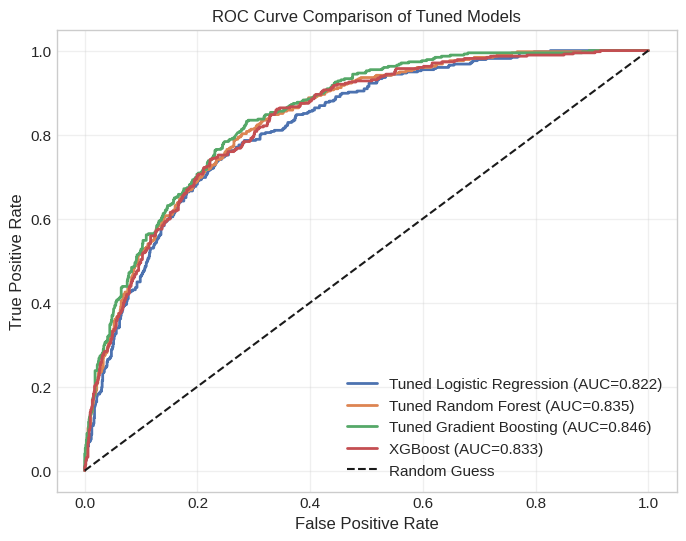

In [21]:
# =========================
# ROC Curve Comparison
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# Tuned Logistic Regression
fpr, tpr, _ = roc_curve(y_test, lr_prob_tuned)
plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Tuned Logistic Regression (AUC={roc_auc_score(y_test, lr_prob_tuned):.3f})"
)

# Tuned Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Tuned Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

# Tuned Gradient Boosting
fpr, tpr, _ = roc_curve(y_test, gb_prob_tuned)
plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Tuned Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob_tuned):.3f})"
)

# XGBoost
if XGBOOST_AVAILABLE:
    fpr, tpr, _ = roc_curve(y_test, xgb_prob)
    plt.plot(
        fpr, tpr,
        linewidth=2,
        label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.3f})"
    )

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()